# 04 — Deep Learning Anomaly Detection (Branch B) v2
**Li-ion Battery Degradation Anomaly Detection Using Deep Learning**

---

## Goals
1. Train 3 autoencoder architectures on **Qualified (normal) data only**
 - LSTM-AE / TCN-AE / Transformer-AE
2. Anomaly score = **reconstruction error**
3. Compare with Branch A baselines and Diao 2020

## v2 Changes (vs v1)
- **Model capacity **: hidden_dim 64->128, latent_dim 16->32, deeper layers
- **TCN-AE**: 3-level encoder + ConvTranspose1d decoder (v1 decoder was effectively bypassed)
- **Training**: epochs 150->300, patience 15->25, warmup + cosine schedule
- **Threshold**: multi-strategy (mean+3σ, mean+2σ, 95th percentile) comparison
- **Anomaly score**: feature-weighted MSE (capacity/cumul_fade get 2× weight)

## 0. Setup & GPU Check

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle
import os
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

PROJECT_DIR = '/content/drive/MyDrive/battery-anomaly-detection'
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'processed_data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
for d in [RESULTS_DIR, MODEL_DIR]:
 os.makedirs(d, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
 print(f' GPU: {torch.cuda.get_device_name(0)}')
 print(f' Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Setup complete.')

Mounted at /content/drive
Device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB
Setup complete.


---
## 1. Load Processed Data

In [2]:
with open(os.path.join(PROCESSED_DIR, 'sliding_windows.pkl'), 'rb') as f:
 window_data = pickle.load(f)

windows_norm = window_data['windows_normalized']
all_metadata = window_data['metadata']
FEATURE_COLS = window_data['feature_cols']
WINDOW_SIZE = window_data['window_size']

gt_d1 = pd.read_csv(os.path.join(PROCESSED_DIR, 'ground_truth_d1.csv'))
gt_d2 = pd.read_csv(os.path.join(PROCESSED_DIR, 'ground_truth_d2.csv'))
diao_baselines = pd.read_csv(os.path.join(PROCESSED_DIR, 'diao2020_baselines.csv'), index_col=0)
baseline_det = pd.read_csv(os.path.join(PROCESSED_DIR, 'baseline_detection_cycles.csv'))

print(f'Window: {WINDOW_SIZE} steps × {len(FEATURE_COLS)} features')
print(f'Features: {FEATURE_COLS}')
for ds in ['Dataset1', 'Dataset2']:
 for grp in ['Qualified', 'Subsequent']:
 d = windows_norm[ds][grp]
 if len(d) > 0:
 print(f' {ds} {grp}: {d.shape}')

# Feature weights for anomaly scoring
# Upweight capacity-related features that directly indicate degradation
FEAT_WEIGHT_MAP = {
 'capacity': 2.0,
 'fade_rate': 1.5,
 'fade_accel': 1.0,
 'rolling_std': 1.0,
 'relative_cap': 2.0,
 'cumul_fade': 2.0,
}
FEAT_WEIGHTS = torch.FloatTensor([FEAT_WEIGHT_MAP[f] for f in FEATURE_COLS]).to(device)
FEAT_WEIGHTS = FEAT_WEIGHTS / FEAT_WEIGHTS.mean() # normalize so mean=1
print(f'\nFeature weights: {dict(zip(FEATURE_COLS, FEAT_WEIGHTS.cpu().numpy().round(3)))}')

Window: 5 steps × 6 features
Features: ['capacity', 'fade_rate', 'fade_accel', 'rolling_std', 'relative_cap', 'cumul_fade']
  Dataset1 Qualified: (2940, 5, 6)
  Dataset1 Subsequent: (2964, 5, 6)
  Dataset2 Qualified: (3416, 5, 6)
  Dataset2 Subsequent: (2196, 5, 6)

Feature weights: {'capacity': np.float32(1.263), 'fade_rate': np.float32(0.947), 'fade_accel': np.float32(0.632), 'rolling_std': np.float32(0.632), 'relative_cap': np.float32(1.263), 'cumul_fade': np.float32(1.263)}


---
## 2. Prepare DataLoaders

In [3]:
BATCH_SIZE = 64
VAL_RATIO = 0.2
SEED = 42

def prepare_dataloaders(dataset_name):
 qual = windows_norm[dataset_name]['Qualified']
 subseq = windows_norm[dataset_name]['Subsequent']

 np.random.seed(SEED)
 n = len(qual)
 idx = np.random.permutation(n)
 val_size = int(n * VAL_RATIO)

 val_idx = idx[:val_size]
 train_idx = idx[val_size:]

 X_train = torch.FloatTensor(qual[train_idx])
 X_val = torch.FloatTensor(qual[val_idx])

 train_loader = DataLoader(TensorDataset(X_train), batch_size=BATCH_SIZE, shuffle=True)
 val_loader = DataLoader(TensorDataset(X_val), batch_size=BATCH_SIZE, shuffle=False)

 print(f'{dataset_name}: train={len(X_train)}, val={len(X_val)}')

 return {'train': train_loader, 'val': val_loader,
 'train_idx': train_idx, 'val_idx': val_idx}

loaders = {}
for ds in ['Dataset1', 'Dataset2']:
 loaders[ds] = prepare_dataloaders(ds)

Dataset1: train=2352, val=588
Dataset2: train=2733, val=683


---
## 3. Model Architectures (v2 — larger capacity)

### 3.1 LSTM-AE v2

In [4]:
class LSTMAutoencoder(nn.Module):
 def __init__(self, n_features=6, hidden_dim=128, latent_dim=32,
 n_layers=2, dropout=0.15):
 super().__init__()
 self.n_features = n_features
 self.hidden_dim = hidden_dim

 # Encoder
 self.encoder = nn.LSTM(
 input_size=n_features, hidden_size=hidden_dim,
 num_layers=n_layers, batch_first=True, dropout=dropout
 )
 self.enc_fc = nn.Sequential(
 nn.Linear(hidden_dim, hidden_dim // 2),
 nn.ReLU(),
 nn.Linear(hidden_dim // 2, latent_dim),
 )

 # Decoder
 self.dec_fc = nn.Sequential(
 nn.Linear(latent_dim, hidden_dim // 2),
 nn.ReLU(),
 nn.Linear(hidden_dim // 2, hidden_dim),
 )
 self.decoder = nn.LSTM(
 input_size=hidden_dim, hidden_size=hidden_dim,
 num_layers=n_layers, batch_first=True, dropout=dropout
 )
 self.output_fc = nn.Sequential(
 nn.Linear(hidden_dim, hidden_dim // 2),
 nn.ReLU(),
 nn.Linear(hidden_dim // 2, n_features),
 )

 def forward(self, x):
 batch_size, seq_len, _ = x.shape
 _, (h, _) = self.encoder(x)
 latent = self.enc_fc(h[-1])
 dec_input = self.dec_fc(latent).unsqueeze(1).repeat(1, seq_len, 1)
 dec_out, _ = self.decoder(dec_input)
 return self.output_fc(dec_out)

print('LSTM-AE v2 defined.')
_t = LSTMAutoencoder().to(device)
_o = _t(torch.randn(2, 5, 6).to(device))
print(f' Shape: (2,5,6) -> {tuple(_o.shape)}')
print(f' Params: {sum(p.numel() for p in _t.parameters()):,}')
del _t, _o

LSTM-AE v2 defined.
  Shape: (2,5,6) → (2, 5, 6)
  Params: 495,334


### 3.2 TCN-AE v2

v1 issue: the decoder had only 0-1 TCN blocks, which limited reconstruction capacity.
v2: 3-level encoder paired with a symmetric `ConvTranspose1d` decoder.


In [5]:
class CausalConv1d(nn.Module):
 def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
 super().__init__()
 self.padding = (kernel_size - 1) * dilation
 self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
 padding=self.padding, dilation=dilation)
 def forward(self, x):
 out = self.conv(x)
 return out[:, :, :-self.padding] if self.padding > 0 else out

class TCNBlock(nn.Module):
 def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.15):
 super().__init__()
 self.net = nn.Sequential(
 CausalConv1d(in_ch, out_ch, kernel_size, dilation),
 nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
 CausalConv1d(out_ch, out_ch, kernel_size, dilation),
 nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
 )
 self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
 self.relu = nn.ReLU()
 def forward(self, x):
 return self.relu(self.net(x) + self.residual(x))

class TCNAutoencoder(nn.Module):
 def __init__(self, n_features=6, enc_channels=[32, 64, 128],
 latent_dim=32, kernel_size=3, dropout=0.15):
 super().__init__()

 # Encoder: 3 TCN blocks with increasing dilation
 enc_layers = []
 in_ch = n_features
 for i, out_ch in enumerate(enc_channels):
 enc_layers.append(TCNBlock(in_ch, out_ch, kernel_size,
 dilation=2**i, dropout=dropout))
 in_ch = out_ch
 self.encoder = nn.Sequential(*enc_layers)
 self.enc_pool = nn.AdaptiveAvgPool1d(1)
 self.enc_fc = nn.Sequential(
 nn.Linear(enc_channels[-1], 64), nn.ReLU(),
 nn.Linear(64, latent_dim),
 )

 # Decoder: FC -> reshape -> ConvTranspose1d blocks (mirror)
 dec_channels = list(reversed(enc_channels)) # [128, 64, 32]
 self.dec_fc = nn.Sequential(
 nn.Linear(latent_dim, 64), nn.ReLU(),
 nn.Linear(64, dec_channels[0]),
 )

 dec_layers = []
 for i in range(len(dec_channels) - 1):
 dec_layers.extend([
 nn.ConvTranspose1d(dec_channels[i], dec_channels[i+1],
 kernel_size=3, padding=1),
 nn.BatchNorm1d(dec_channels[i+1]),
 nn.ReLU(),
 nn.Dropout(dropout),
 ])
 self.decoder = nn.Sequential(*dec_layers)
 self.output_conv = nn.Conv1d(dec_channels[-1], n_features, 1)

 def forward(self, x):
 B, T, F = x.shape
 # Encode
 enc = self.encoder(x.transpose(1, 2)) # (B, C, T)
 pooled = self.enc_pool(enc).squeeze(-1) # (B, C)
 latent = self.enc_fc(pooled) # (B, latent)
 # Decode
 dec = self.dec_fc(latent).unsqueeze(-1).repeat(1, 1, T) # (B, C, T)
 dec = self.decoder(dec)
 out = self.output_conv(dec) # (B, F, T)
 return out.transpose(1, 2) # (B, T, F)

print('TCN-AE v2 defined.')
_t = TCNAutoencoder().to(device)
_o = _t(torch.randn(2, 5, 6).to(device))
print(f' Shape: (2,5,6) -> {tuple(_o.shape)}')
print(f' Params: {sum(p.numel() for p in _t.parameters()):,}')
del _t, _o

TCN-AE v2 defined.
  Shape: (2,5,6) → (2, 5, 6)
  Params: 159,782


### 3.3 Transformer-AE v2

In [6]:
class PositionalEncoding(nn.Module):
 def __init__(self, d_model, max_len=500):
 super().__init__()
 pe = torch.zeros(max_len, d_model)
 pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
 div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
 pe[:, 0::2] = torch.sin(pos * div)
 pe[:, 1::2] = torch.cos(pos * div[:d_model//2]) if d_model % 2 == 0 else torch.cos(pos * div[:-1])
 self.register_buffer('pe', pe.unsqueeze(0))
 def forward(self, x):
 return x + self.pe[:, :x.size(1), :]

class TransformerAutoencoder(nn.Module):
 def __init__(self, n_features=6, d_model=128, nhead=8, num_layers=3,
 latent_dim=32, dim_feedforward=256, dropout=0.1):
 super().__init__()
 self.input_proj = nn.Sequential(
 nn.Linear(n_features, d_model),
 nn.LayerNorm(d_model),
 )
 self.pos_enc = PositionalEncoding(d_model)

 enc_layer = nn.TransformerEncoderLayer(
 d_model=d_model, nhead=nhead,
 dim_feedforward=dim_feedforward, dropout=dropout,
 batch_first=True, norm_first=True
 )
 self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
 self.enc_fc = nn.Sequential(
 nn.Linear(d_model, d_model // 2), nn.GELU(),
 nn.Linear(d_model // 2, latent_dim),
 )

 self.dec_fc = nn.Sequential(
 nn.Linear(latent_dim, d_model // 2), nn.GELU(),
 nn.Linear(d_model // 2, d_model),
 )
 dec_layer = nn.TransformerEncoderLayer(
 d_model=d_model, nhead=nhead,
 dim_feedforward=dim_feedforward, dropout=dropout,
 batch_first=True, norm_first=True
 )
 self.decoder = nn.TransformerEncoder(dec_layer, num_layers=num_layers)
 self.output_proj = nn.Sequential(
 nn.Linear(d_model, d_model // 2), nn.GELU(),
 nn.Linear(d_model // 2, n_features),
 )

 def forward(self, x):
 B, T, _ = x.shape
 enc = self.pos_enc(self.input_proj(x))
 enc = self.encoder(enc)
 latent = self.enc_fc(enc.mean(dim=1))
 dec = self.dec_fc(latent).unsqueeze(1).repeat(1, T, 1)
 dec = self.pos_enc(dec)
 dec = self.decoder(dec)
 return self.output_proj(dec)

print('Transformer-AE v2 defined.')
_t = TransformerAutoencoder().to(device)
_o = _t(torch.randn(2, 5, 6).to(device))
print(f' Shape: (2,5,6) -> {tuple(_o.shape)}')
print(f' Params: {sum(p.numel() for p in _t.parameters()):,}')
del _t, _o

Transformer-AE v2 defined.
  Shape: (2,5,6) → (2, 5, 6)
  Params: 825,446


---
## 4. Training Loop v2

Changes: epochs 300, patience 25, CosineAnnealingWarmRestarts, gradient clipping.

In [7]:
def train_autoencoder(model, loaders, model_name, dataset_name,
 epochs=300, lr=1e-3, patience=25):
 model = model.to(device)
 optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
 scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
 optimizer, T_0=50, T_mult=2, eta_min=1e-6
 )
 criterion = nn.MSELoss()

 best_val_loss = float('inf')
 patience_counter = 0
 history = {'train_loss': [], 'val_loss': [], 'lr': []}
 best_state = None
 start = time.time()

 for epoch in range(epochs):
 # Train
 model.train()
 t_losses = []
 for (batch,) in loaders['train']:
 batch = batch.to(device)
 optimizer.zero_grad()
 out = model(batch)
 loss = criterion(out, batch)
 loss.backward()
 torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
 optimizer.step()
 t_losses.append(loss.item())

 # Validate
 model.eval()
 v_losses = []
 with torch.no_grad():
 for (batch,) in loaders['val']:
 batch = batch.to(device)
 out = model(batch)
 v_losses.append(criterion(out, batch).item())

 t_loss = np.mean(t_losses)
 v_loss = np.mean(v_losses)
 cur_lr = optimizer.param_groups[0]['lr']
 history['train_loss'].append(t_loss)
 history['val_loss'].append(v_loss)
 history['lr'].append(cur_lr)

 scheduler.step()

 if v_loss < best_val_loss:
 best_val_loss = v_loss
 patience_counter = 0
 best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
 else:
 patience_counter += 1

 if (epoch + 1) % 30 == 0 or epoch == 0:
 print(f' Epoch {epoch+1:3d}/{epochs} | '
 f'Train: {t_loss:.6f} | Val: {v_loss:.6f} | '
 f'Best: {best_val_loss:.6f} | LR: {cur_lr:.1e} | {time.time()-start:.0f}s')

 if patience_counter >= patience:
 print(f' Early stopping at epoch {epoch+1}')
 break

 model.load_state_dict(best_state)
 model = model.to(device)

 total = time.time() - start
 print(f' {model_name}/{dataset_name} | Best val: {best_val_loss:.6f} | {total:.1f}s')

 torch.save({'model_state': best_state, 'history': history,
 'best_val_loss': best_val_loss},
 os.path.join(MODEL_DIR, f'{model_name}_{dataset_name}_v2.pt'))

 return model, history

print('Training function v2 defined.')

Training function v2 defined.


---
## 5. Train All Models (v2)

In [8]:
model_configs = {
 'LSTM_AE': lambda: LSTMAutoencoder(
 n_features=6, hidden_dim=128, latent_dim=32, n_layers=2, dropout=0.15
 ),
 'TCN_AE': lambda: TCNAutoencoder(
 n_features=6, enc_channels=[32, 64, 128], latent_dim=32,
 kernel_size=3, dropout=0.15
 ),
 'Transformer_AE': lambda: TransformerAutoencoder(
 n_features=6, d_model=128, nhead=8, num_layers=3,
 latent_dim=32, dim_feedforward=256, dropout=0.1
 ),
}

trained_models = {}
all_histories = {}

for model_name, model_fn in model_configs.items():
 for ds in ['Dataset1', 'Dataset2']:
 print(f'\n{"="*60}')
 print(f'Training {model_name} on {ds}')
 print(f'{"="*60}')
 model = model_fn()
 model, history = train_autoencoder(
 model, loaders[ds], model_name, ds,
 epochs=300, lr=1e-3, patience=25
 )
 trained_models[(model_name, ds)] = model
 all_histories[(model_name, ds)] = history

print(f'\n=== All {len(trained_models)} models trained ===')


Training LSTM_AE on Dataset1
  Epoch   1/300 | Train: 0.850654 | Val: 0.638137 | Best: 0.638137 | LR: 1.0e-03 | 1s
  Epoch  30/300 | Train: 0.298974 | Val: 0.317563 | Best: 0.315190 | LR: 3.8e-04 | 8s
  Epoch  60/300 | Train: 0.271801 | Val: 0.271886 | Best: 0.271886 | LR: 9.8e-04 | 15s
  Epoch  90/300 | Train: 0.109278 | Val: 0.169433 | Best: 0.159336 | LR: 6.7e-04 | 22s
  Epoch 120/300 | Train: 0.073272 | Val: 0.097034 | Best: 0.096049 | LR: 2.2e-04 | 30s
  Epoch 150/300 | Train: 0.069920 | Val: 0.092280 | Best: 0.092269 | LR: 1.2e-06 | 37s
  Epoch 180/300 | Train: 0.062163 | Val: 0.076679 | Best: 0.075123 | LR: 9.5e-04 | 44s
  Epoch 210/300 | Train: 0.046680 | Val: 0.065316 | Best: 0.065316 | LR: 8.0e-04 | 51s
  Epoch 240/300 | Train: 0.041199 | Val: 0.061117 | Best: 0.059745 | LR: 5.9e-04 | 59s
  Epoch 270/300 | Train: 0.035396 | Val: 0.056003 | Best: 0.054814 | LR: 3.5e-04 | 65s
  Epoch 300/300 | Train: 0.031781 | Val: 0.052363 | Best: 0.052363 | LR: 1.5e-04 | 73s
  ✓ LSTM_AE/Dat

---
## 6. Training Curves

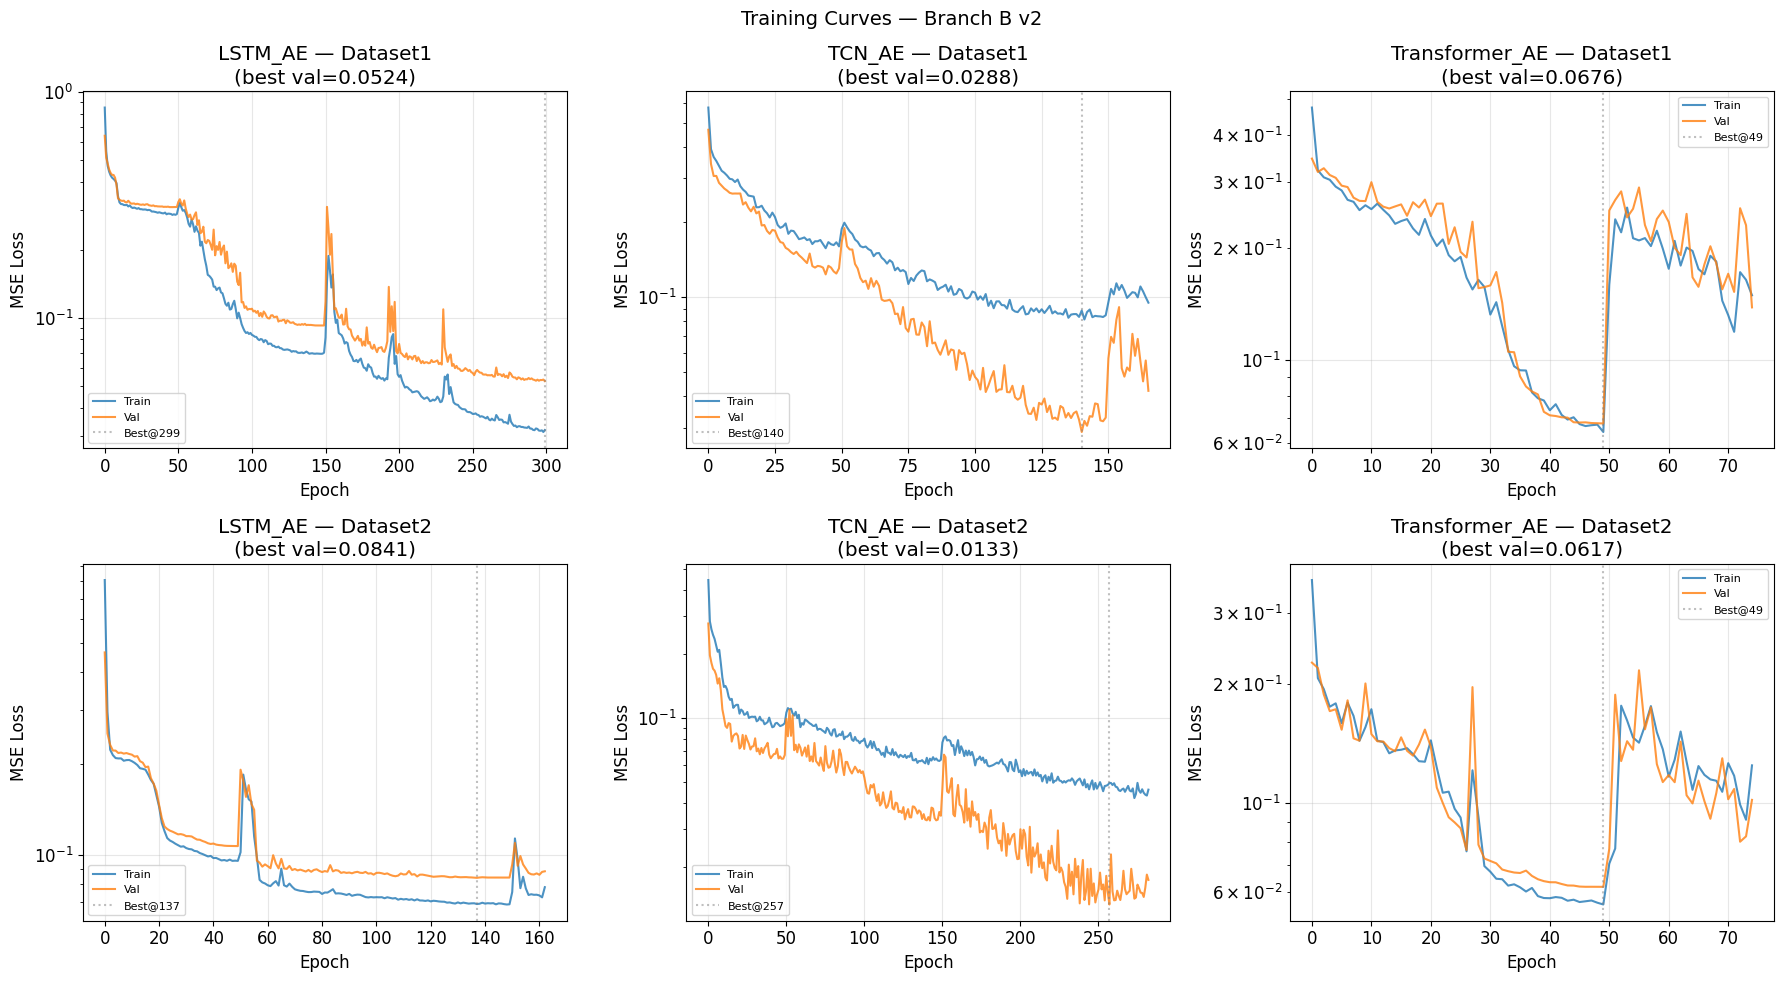

✓ Saved: fig13_training_curves_v2.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, model_name in enumerate(model_configs.keys()):
 for row, ds in enumerate(['Dataset1', 'Dataset2']):
 ax = axes[row, col]
 h = all_histories[(model_name, ds)]
 ax.plot(h['train_loss'], label='Train', linewidth=1.5, alpha=0.8)
 ax.plot(h['val_loss'], label='Val', linewidth=1.5, alpha=0.8)
 best_epoch = np.argmin(h['val_loss'])
 ax.axvline(best_epoch, color='gray', ls=':', alpha=0.5, label=f'Best@{best_epoch}')
 ax.set_title(f'{model_name} — {ds}\n(best val={min(h["val_loss"]):.4f})')
 ax.set_xlabel('Epoch')
 ax.set_ylabel('MSE Loss')
 ax.legend(fontsize=8)
 ax.set_yscale('log')

plt.suptitle('Training Curves — Branch B v2', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig13_training_curves_v2.png'),
 dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig13_training_curves_v2.png')

---
## 7. Anomaly Scores (Feature-Weighted MSE)

v2: weight `capacity`, `relative_cap`, and `cumul_fade` 2x to emphasize degradation-related signals.


In [10]:
def compute_weighted_errors(model, data_tensor, feat_weights):
 """Compute feature-weighted per-window MSE."""
 model.eval()
 loader = DataLoader(TensorDataset(data_tensor), batch_size=BATCH_SIZE, shuffle=False)
 errors = []
 with torch.no_grad():
 for (batch,) in loader:
 batch = batch.to(device)
 out = model(batch)
 # Weighted MSE: (B, T, F) * (F,) -> mean over T -> (B,)
 sq_err = (out - batch) ** 2 # (B, T, F)
 weighted = sq_err * feat_weights.unsqueeze(0).unsqueeze(0) # broadcast
 mse = weighted.mean(dim=(1, 2)) # (B,)
 errors.append(mse.cpu().numpy())
 return np.concatenate(errors)

def map_windows_to_cycles(errors, metadata_list):
 """Map per-window scores to per-cycle via averaging overlapping windows."""
 cycle_scores = {}
 for i, meta in enumerate(metadata_list):
 for cyc in range(meta['start_cycle'], meta['end_cycle'] + 1):
 if cyc not in cycle_scores:
 cycle_scores[cyc] = []
 cycle_scores[cyc].append(errors[i])
 cycles = sorted(cycle_scores.keys())
 scores = np.array([np.mean(cycle_scores[c]) for c in cycles])
 return np.array(cycles), scores

def compute_percycle_scores(model, dataset_name):
 """Per-cell, per-cycle anomaly scores."""
 results = {}
 for grp in ['Qualified', 'Subsequent']:
 data = windows_norm[dataset_name][grp]
 meta_list = all_metadata[dataset_name][grp]
 if len(data) == 0:
 continue

 all_errors = compute_weighted_errors(
 model, torch.FloatTensor(data), FEAT_WEIGHTS
 )

 cell_windows = {}
 for i, meta in enumerate(meta_list):
 cid = meta['cell_id']
 if cid not in cell_windows:
 cell_windows[cid] = []
 cell_windows[cid].append((i, meta))

 for cell_id, windows in cell_windows.items():
 indices = [w[0] for w in windows]
 cell_errors = all_errors[indices]
 cell_meta = [w[1] for w in windows]
 cycles, scores = map_windows_to_cycles(cell_errors, cell_meta)
 results[cell_id] = {'cycles': cycles, 'scores': scores, 'group': grp}

 return results

# Compute for all models
dl_results = {}
for model_name in model_configs.keys():
 dl_results[model_name] = {}
 for ds in ['Dataset1', 'Dataset2']:
 model = trained_models[(model_name, ds)]
 dl_results[model_name][ds] = compute_percycle_scores(model, ds)
 n = len(dl_results[model_name][ds])
 print(f'{model_name}/{ds}: {n} cells scored')

print('\n All weighted reconstruction errors computed.')

LSTM_AE/Dataset1: 12 cells scored
LSTM_AE/Dataset2: 23 cells scored
TCN_AE/Dataset1: 12 cells scored
TCN_AE/Dataset2: 23 cells scored
Transformer_AE/Dataset1: 12 cells scored
Transformer_AE/Dataset2: 23 cells scored

✓ All weighted reconstruction errors computed.


---
## 8. Anomaly Score Visualization

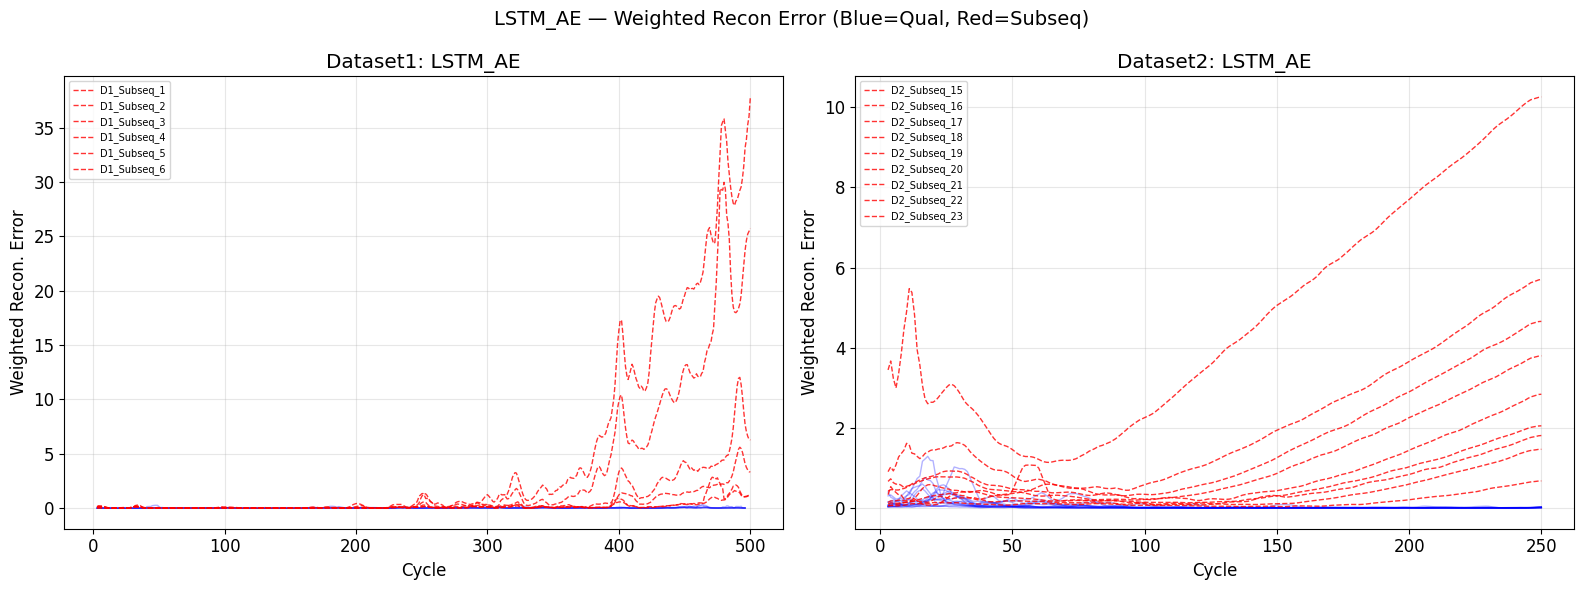

✓ fig14_lstm_ae_scores_v2.png


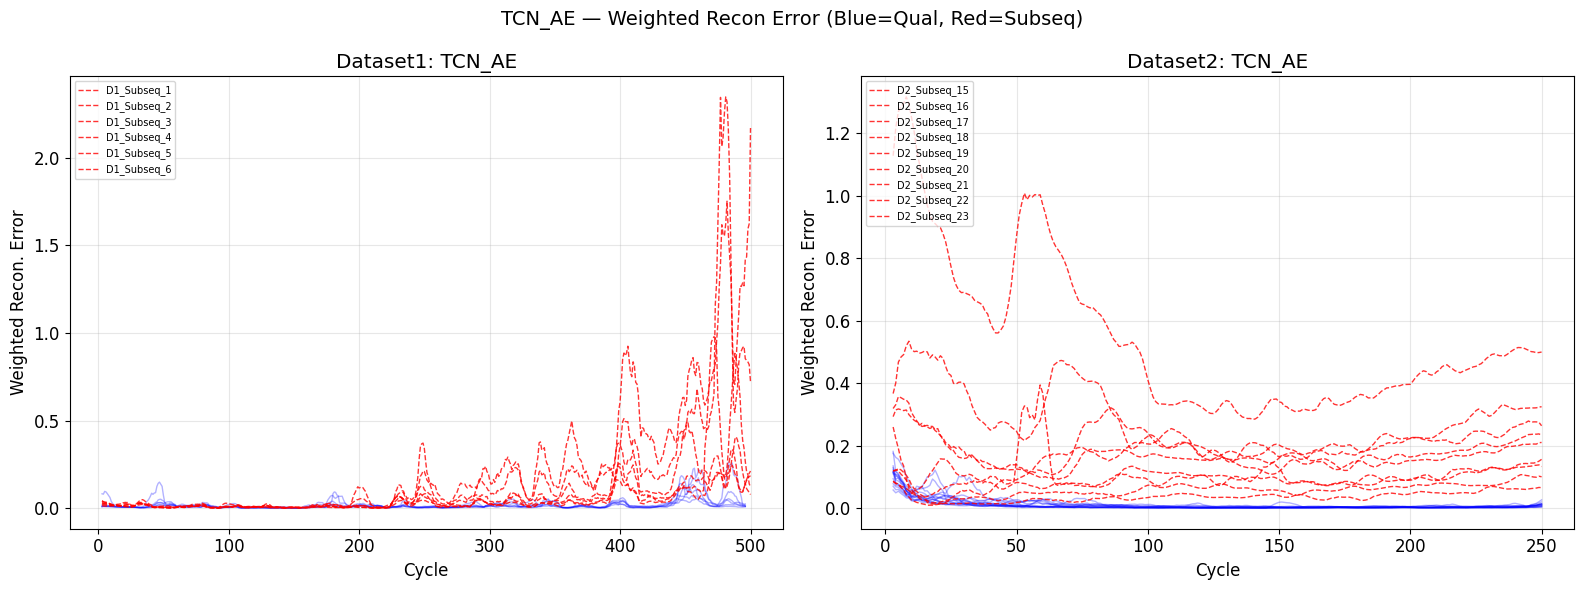

✓ fig14_tcn_ae_scores_v2.png


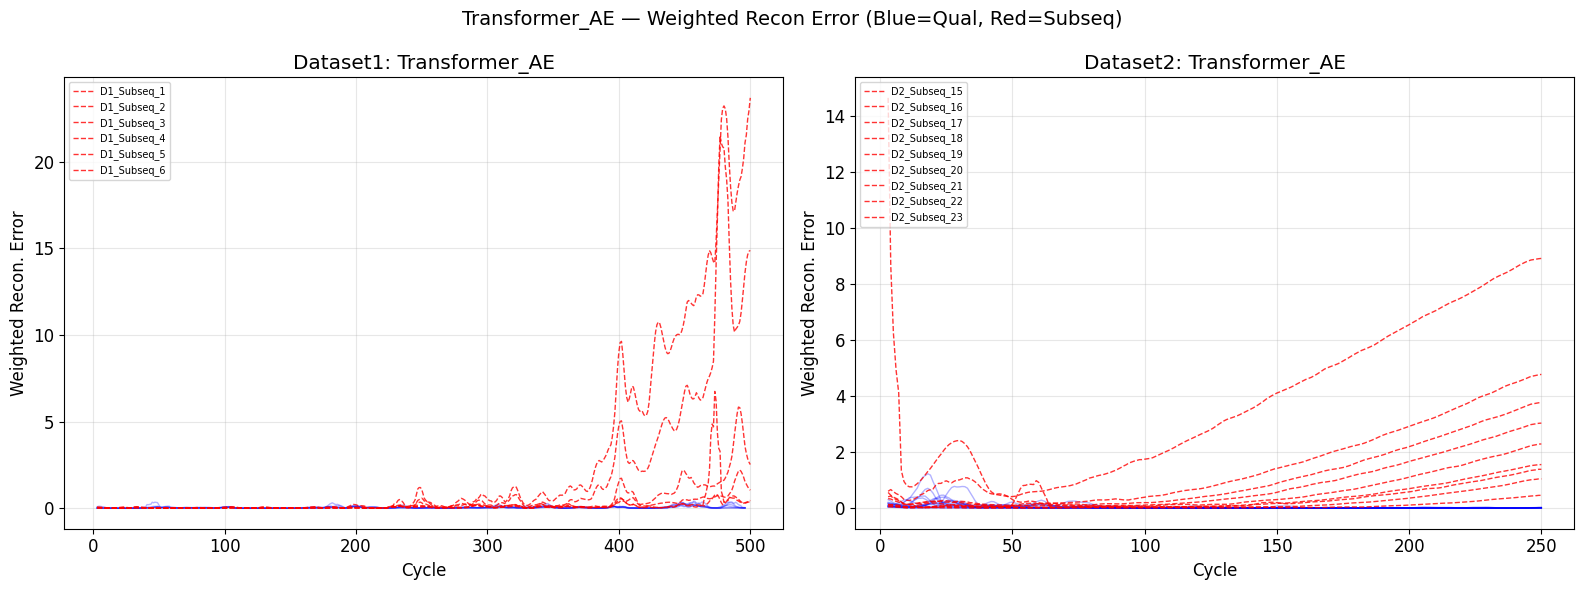

✓ fig14_transformer_ae_scores_v2.png


In [11]:
def plot_dl_scores(dl_results, model_name, save_path=None):
 fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 for idx, ds in enumerate(['Dataset1', 'Dataset2']):
 ax = axes[idx]
 results = dl_results[model_name][ds]
 for cell_id, res in sorted(results.items()):
 c = 'blue' if res['group']=='Qualified' else 'red'
 ls = '-' if res['group']=='Qualified' else '--'
 a = 0.3 if res['group']=='Qualified' else 0.8
 ax.plot(res['cycles'], res['scores'], color=c, ls=ls, alpha=a, lw=1,
 label=cell_id if res['group']=='Subsequent' else None)
 ax.set_title(f'{ds}: {model_name}')
 ax.set_xlabel('Cycle')
 ax.set_ylabel('Weighted Recon. Error')
 ax.legend(fontsize=7, loc='upper left')
 plt.suptitle(f'{model_name} — Weighted Recon Error (Blue=Qual, Red=Subseq)', fontsize=14)
 plt.tight_layout()
 if save_path:
 plt.savefig(save_path, dpi=150, bbox_inches='tight')
 plt.show()

for mn in model_configs.keys():
 sp = os.path.join(RESULTS_DIR, f'fig14_{mn.lower()}_scores_v2.png')
 plot_dl_scores(dl_results, mn, save_path=sp)
 print(f' {os.path.basename(sp)}')

---
## 9. Detection Cycle - Multi-Threshold Comparison

Compare three threshold strategies and select the most appropriate:
- **mean + 3 * std**: conservative (matches v1)
- **mean + 2 * std**: intermediate
- **95th percentile**: data-driven


In [12]:
def estimate_detection_multi_threshold(dl_results, model_name,
 n_consec=5):
 """
 Estimate detection cycle with multiple threshold strategies.
 """
 rows = []

 for ds in ['Dataset1', 'Dataset2']:
 results = dl_results[model_name][ds]

 qual_scores = np.concatenate([
 res['scores'] for res in results.values()
 if res['group'] == 'Qualified'
 ])

 thresholds = {
 'mean+3σ': np.mean(qual_scores) + 3 * np.std(qual_scores),
 'mean+2σ': np.mean(qual_scores) + 2 * np.std(qual_scores),
 'P95': np.percentile(qual_scores, 95),
 }

 for cell_id, res in results.items():
 for thr_name, thr_val in thresholds.items():
 above = res['scores'] > thr_val
 det_cycle = None
 for i in range(len(above) - n_consec + 1):
 if all(above[i:i+n_consec]):
 det_cycle = int(res['cycles'][i])
 break

 rows.append({
 'dataset': ds, 'cell_id': cell_id,
 'group': res['group'], 'method': model_name,
 'threshold_type': thr_name,
 'threshold_value': thr_val,
 'detection_cycle': det_cycle,
 'max_score': float(res['scores'].max()),
 })

 return pd.DataFrame(rows)

# All models, all thresholds
all_det = []
for mn in model_configs.keys():
 det = estimate_detection_multi_threshold(dl_results, mn)
 all_det.append(det)
dl_detection_df = pd.concat(all_det, ignore_index=True)

# Show D1 Subsequent detection cycles for each threshold strategy
print('=== Detection Cycles — D1 Subsequent ===')
for thr in ['mean+3σ', 'mean+2σ', 'P95']:
 print(f'\n--- Threshold: {thr} ---')
 sub = dl_detection_df[
 (dl_detection_df['dataset']=='Dataset1') &
 (dl_detection_df['group']=='Subsequent') &
 (dl_detection_df['threshold_type']==thr)
 ]
 pivot = sub.pivot_table(
 index='cell_id', columns='method',
 values='detection_cycle', aggfunc='first'
 )
 display(pivot)

# Mean detection per threshold
print('\n=== Mean Detection Cycle (D1 Subsequent) ===')
d1_sub = dl_detection_df[
 (dl_detection_df['dataset']=='Dataset1') &
 (dl_detection_df['group']=='Subsequent') &
 (dl_detection_df['detection_cycle'].notna())
]
mean_det = d1_sub.groupby(['threshold_type', 'method'])['detection_cycle'].mean().unstack()
display(mean_det.round(1))
print(f'\nDiao 2020 mean: {diao_baselines.values.mean():.1f}')

=== Detection Cycles — D1 Subsequent ===

--- Threshold: mean+3σ ---


method,LSTM_AE,TCN_AE,Transformer_AE
cell_id,,,
D1_Subseq_1,3.0,229.0,229.0
D1_Subseq_2,3.0,198.0,246.0
D1_Subseq_3,31.0,246.0,246.0
D1_Subseq_4,31.0,395.0,397.0
D1_Subseq_5,287.0,394.0,396.0
D1_Subseq_6,248.0,395.0,398.0



--- Threshold: mean+2σ ---


method,LSTM_AE,TCN_AE,Transformer_AE
cell_id,,,
D1_Subseq_1,3.0,228.0,229.0
D1_Subseq_2,3.0,196.0,196.0
D1_Subseq_3,4.0,245.0,245.0
D1_Subseq_4,4.0,394.0,317.0
D1_Subseq_5,248.0,393.0,289.0
D1_Subseq_6,30.0,394.0,396.0



--- Threshold: P95 ---


method,LSTM_AE,TCN_AE,Transformer_AE
cell_id,,,
D1_Subseq_1,3.0,228.0,229.0
D1_Subseq_2,3.0,196.0,197.0
D1_Subseq_3,4.0,244.0,245.0
D1_Subseq_4,4.0,246.0,317.0
D1_Subseq_5,227.0,393.0,395.0
D1_Subseq_6,30.0,228.0,397.0



=== Mean Detection Cycle (D1 Subsequent) ===


method,LSTM_AE,TCN_AE,Transformer_AE
threshold_type,,,
P95,45.2,255.8,296.7
mean+2σ,48.7,308.3,278.7
mean+3σ,100.5,309.5,318.7



Diao 2020 mean: 179.6


---
## 10. False Positive Analysis

In [13]:
# Check FP for best threshold (P95)
print('=== False Positives (Qualified cells flagged) ===')
for thr in ['mean+3σ', 'mean+2σ', 'P95']:
 fp = dl_detection_df[
 (dl_detection_df['group']=='Qualified') &
 (dl_detection_df['threshold_type']==thr) &
 (dl_detection_df['detection_cycle'].notna())
 ]
 n_total_qual = dl_detection_df[
 (dl_detection_df['group']=='Qualified') &
 (dl_detection_df['threshold_type']==thr)
 ].shape[0]

 print(f'\n--- {thr}: {len(fp)} FP / {n_total_qual} qualified ---')
 if len(fp) > 0:
 display(fp[['dataset','cell_id','method','detection_cycle']].head(20))

=== False Positives (Qualified cells flagged) ===

--- mean+3σ: 38 FP / 60 qualified ---


,dataset,cell_id,method,detection_cycle
0,Dataset1,D1_Qual_1,LSTM_AE,460.0
3,Dataset1,D1_Qual_2,LSTM_AE,41.0
6,Dataset1,D1_Qual_3,LSTM_AE,450.0
12,Dataset1,D1_Qual_5,LSTM_AE,460.0
15,Dataset1,D1_Qual_6,LSTM_AE,180.0
36,Dataset2,D2_Qual_1,LSTM_AE,24.0
39,Dataset2,D2_Qual_2,LSTM_AE,13.0
42,Dataset2,D2_Qual_3,LSTM_AE,12.0
54,Dataset2,D2_Qual_7,LSTM_AE,11.0
57,Dataset2,D2_Qual_8,LSTM_AE,21.0



--- mean+2σ: 50 FP / 60 qualified ---


,dataset,cell_id,method,detection_cycle
1,Dataset1,D1_Qual_1,LSTM_AE,233.0
4,Dataset1,D1_Qual_2,LSTM_AE,41.0
7,Dataset1,D1_Qual_3,LSTM_AE,448.0
10,Dataset1,D1_Qual_4,LSTM_AE,344.0
13,Dataset1,D1_Qual_5,LSTM_AE,445.0
16,Dataset1,D1_Qual_6,LSTM_AE,179.0
37,Dataset2,D2_Qual_1,LSTM_AE,24.0
40,Dataset2,D2_Qual_2,LSTM_AE,12.0
43,Dataset2,D2_Qual_3,LSTM_AE,10.0
46,Dataset2,D2_Qual_4,LSTM_AE,18.0



--- P95: 52 FP / 60 qualified ---


,dataset,cell_id,method,detection_cycle
2,Dataset1,D1_Qual_1,LSTM_AE,232.0
5,Dataset1,D1_Qual_2,LSTM_AE,41.0
8,Dataset1,D1_Qual_3,LSTM_AE,398.0
11,Dataset1,D1_Qual_4,LSTM_AE,344.0
14,Dataset1,D1_Qual_5,LSTM_AE,445.0
17,Dataset1,D1_Qual_6,LSTM_AE,179.0
38,Dataset2,D2_Qual_1,LSTM_AE,22.0
41,Dataset2,D2_Qual_2,LSTM_AE,11.0
44,Dataset2,D2_Qual_3,LSTM_AE,3.0
47,Dataset2,D2_Qual_4,LSTM_AE,17.0


---
## 11. Select Best Threshold and Final Results

Choose the optimal threshold by balancing the false-positive rate against detection earliness.


In [14]:
# Select best threshold per model: lowest mean detection cycle with ≤2 FP per dataset
print('=== Threshold Selection ===')
best_threshold = {}

for mn in model_configs.keys():
 print(f'\n{mn}:')
 for thr in ['P95', 'mean+2σ', 'mean+3σ']: # try aggressive first
 # Count FP
 fp_count = dl_detection_df[
 (dl_detection_df['method']==mn) &
 (dl_detection_df['group']=='Qualified') &
 (dl_detection_df['threshold_type']==thr) &
 (dl_detection_df['detection_cycle'].notna())
 ].shape[0]

 # Mean detection for subsequent
 sub_det = dl_detection_df[
 (dl_detection_df['method']==mn) &
 (dl_detection_df['group']=='Subsequent') &
 (dl_detection_df['threshold_type']==thr) &
 (dl_detection_df['detection_cycle'].notna())
 ]['detection_cycle']
 mean_d = sub_det.mean() if len(sub_det) > 0 else float('inf')
 n_detected = len(sub_det)

 print(f' {thr}: FP={fp_count}, detected={n_detected}/15, mean_cycle={mean_d:.1f}')

 if mn not in best_threshold:
 # Pick first threshold with acceptable FP (≤ 3 late-stage FP)
 late_fp = dl_detection_df[
 (dl_detection_df['method']==mn) &
 (dl_detection_df['group']=='Qualified') &
 (dl_detection_df['threshold_type']==thr) &
 (dl_detection_df['detection_cycle'].notna()) &
 (dl_detection_df['detection_cycle'] < 300) # early FP is worse
 ].shape[0]
 if late_fp <= 2:
 best_threshold[mn] = thr
 print(f' -> Selected: {thr}')

# Fallback to mean+3σ if nothing selected
for mn in model_configs.keys():
 if mn not in best_threshold:
 best_threshold[mn] = 'mean+3σ'
 print(f'{mn}: fallback to mean+3σ')

print(f'\nBest thresholds: {best_threshold}')

# Extract final detection table with best thresholds
final_det_rows = []
for mn in model_configs.keys():
 thr = best_threshold[mn]
 sub = dl_detection_df[
 (dl_detection_df['method']==mn) &
 (dl_detection_df['threshold_type']==thr)
 ].copy()
 final_det_rows.append(sub)

final_detection_df = pd.concat(final_det_rows, ignore_index=True)

# Final detection pivot
print('\n=== Final Detection Cycles (best threshold per model) ===')
final_sub = final_detection_df[final_detection_df['group']=='Subsequent']
final_pivot = final_sub.pivot_table(
 index=['dataset','cell_id'], columns='method',
 values='detection_cycle', aggfunc='first'
)
display(final_pivot)

=== Threshold Selection ===

LSTM_AE:
  P95: FP=16, detected=15/15, mean_cycle=35.8
  mean+2σ: FP=16, detected=15/15, mean_cycle=47.9
  mean+3σ: FP=11, detected=15/15, mean_cycle=74.2

TCN_AE:
  P95: FP=20, detected=15/15, mean_cycle=104.1
  mean+2σ: FP=19, detected=15/15, mean_cycle=125.1
  mean+3σ: FP=14, detected=15/15, mean_cycle=140.7

Transformer_AE:
  P95: FP=16, detected=15/15, mean_cycle=156.4
  mean+2σ: FP=15, detected=15/15, mean_cycle=153.3
  mean+3σ: FP=13, detected=15/15, mean_cycle=187.0
LSTM_AE: fallback to mean+3σ
TCN_AE: fallback to mean+3σ
Transformer_AE: fallback to mean+3σ

Best thresholds: {'LSTM_AE': 'mean+3σ', 'TCN_AE': 'mean+3σ', 'Transformer_AE': 'mean+3σ'}

=== Final Detection Cycles (best threshold per model) ===


method                 LSTM_AE  TCN_AE  Transformer_AE
dataset  cell_id                                      
Dataset1 D1_Subseq_1       3.0   229.0           229.0
         D1_Subseq_2       3.0   198.0           246.0
         D1_Subseq_3      31.0   246.0           246.0
         D1_Subseq_4      31.0   395.0           397.0
         D1_Subseq_5     287.0   394.0           396.0
         D1_Subseq_6     248.0   395.0           398.0
Dataset2 D2_Subseq_15     28.0     3.0           168.0
         D2_Subseq_16    183.0     3.0           194.0
         D2_Subseq_17      3.0     3.0           128.0
         D2_Subseq_18     51.0     3.0             3.0
         D2_Subseq_19      3.0     3.0           113.0
         D2_Subseq_20      3.0     3.0             3.0
         D2_Subseq_21      3.0     3.0             3.0
         D2_Subseq_22    221.0   229.0           230.0
         D2_Subseq_23     15.0     3.0            51.0

---
## 12. Cell-Level AUC

In [15]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def compute_dl_cell_metrics(dl_results, model_name):
 rows = []
 for ds in ['Dataset1', 'Dataset2']:
 for cell_id, res in dl_results[model_name][ds].items():
 rows.append({
 'dataset': ds, 'cell_id': cell_id,
 'group': res['group'], 'method': model_name,
 'max_score': float(res['scores'].max()),
 'mean_score': float(res['scores'].mean()),
 'label': 1 if res['group']=='Subsequent' else 0,
 })
 return pd.DataFrame(rows)

dl_cell_scores = pd.concat([
 compute_dl_cell_metrics(dl_results, mn)
 for mn in model_configs.keys()
], ignore_index=True)

dl_auc_results = []
for ds in ['Dataset1', 'Dataset2']:
 for method in dl_cell_scores['method'].unique():
 s = dl_cell_scores[(dl_cell_scores['dataset']==ds) & (dl_cell_scores['method']==method)]
 y_true, y_score = s['label'].values, s['max_score'].values
 try: roc = roc_auc_score(y_true, y_score)
 except: roc = np.nan
 try:
 p, r, _ = precision_recall_curve(y_true, y_score)
 pr = auc(r, p)
 except: pr = np.nan
 dl_auc_results.append({'dataset': ds, 'method': method,
 'ROC_AUC': roc, 'PR_AUC': pr,
 'n_normal': int((y_true==0).sum()),
 'n_anomaly': int((y_true==1).sum())})

dl_auc_df = pd.DataFrame(dl_auc_results)
print('=== Branch B v2 Cell-Level AUC ===')
display(dl_auc_df.round(4))

=== Branch B v2 Cell-Level AUC ===


,dataset,method,ROC_AUC,PR_AUC,n_normal,n_anomaly
0,Dataset1,LSTM_AE,1.0000,1.0000,6,6
1,Dataset1,TCN_AE,1.0000,1.0000,6,6
2,Dataset1,Transformer_AE,1.0000,1.0000,6,6
3,Dataset2,LSTM_AE,0.9762,0.9710,14,9
4,Dataset2,TCN_AE,0.8175,0.8475,14,9
5,Dataset2,Transformer_AE,0.9603,0.9513,14,9


---
## 13. Comparison: Branch A vs Branch B v2 vs Diao 2020

In [16]:
baseline_auc = pd.read_csv(os.path.join(PROCESSED_DIR, 'baseline_auc_metrics.csv'))
baseline_auc['branch'] = 'A (Baseline)'
dl_auc_df['branch'] = 'B (DL v2)'
combined_auc = pd.concat([baseline_auc, dl_auc_df], ignore_index=True)

print('=== Combined AUC: Branch A vs Branch B v2 ===')
display(combined_auc.pivot_table(
 index=['branch','method'], columns='dataset',
 values=['ROC_AUC','PR_AUC']
).round(4))

# Detection cycle comparison (use best threshold for B)
print('\n=== Mean Detection Cycle — D1 Subsequent ===')

# Branch A
ba = baseline_det[
 (baseline_det['dataset']=='Dataset1') &
 (baseline_det['group']=='Subsequent') &
 (baseline_det['detection_cycle'].notna())
]
print('Branch A:')
print(ba.groupby('method')['detection_cycle'].mean().round(1))

# Branch B (best threshold)
bb = final_detection_df[
 (final_detection_df['dataset']=='Dataset1') &
 (final_detection_df['group']=='Subsequent') &
 (final_detection_df['detection_cycle'].notna())
]
print(f'\nBranch B v2 (best threshold):')
print(bb.groupby('method')['detection_cycle'].mean().round(1))

print(f'\nDiao 2020 mean: {diao_baselines.values.mean():.1f}')
print(f'Diao 2020 earliest/cell: {diao_baselines.min().mean():.1f}')

=== Combined AUC: Branch A vs Branch B v2 ===


PR_AUC           ROC_AUC         
dataset                           Dataset1 Dataset2 Dataset1 Dataset2
branch       method                                                  
A (Baseline) LOF                    1.0000   1.0000   1.0000   1.0000
             Mahalanobis Distance   0.7616   0.8359   0.6667   0.8254
             OC-SVM                 0.9742   0.8984   0.9722   0.9206
             SPRT                   1.0000   0.9883   1.0000   0.9921
B (DL v2)    LSTM_AE                1.0000   0.9710   1.0000   0.9762
             TCN_AE                 1.0000   0.8475   1.0000   0.8175
             Transformer_AE         1.0000   0.9513   1.0000   0.9603


=== Mean Detection Cycle — D1 Subsequent ===
Branch A:
method
LOF                     143.5
Mahalanobis Distance    348.7
OC-SVM                  262.7
SPRT                    368.7
Name: detection_cycle, dtype: float64

Branch B v2 (best threshold):
method
LSTM_AE           100.5
TCN_AE            309.5
Transformer_AE    318.7
Name: detection_cycle, dtype: float64

Diao 2020 mean: 179.6
Diao 2020 earliest/cell: 166.3


---
## 14. Reconstruction Visualization

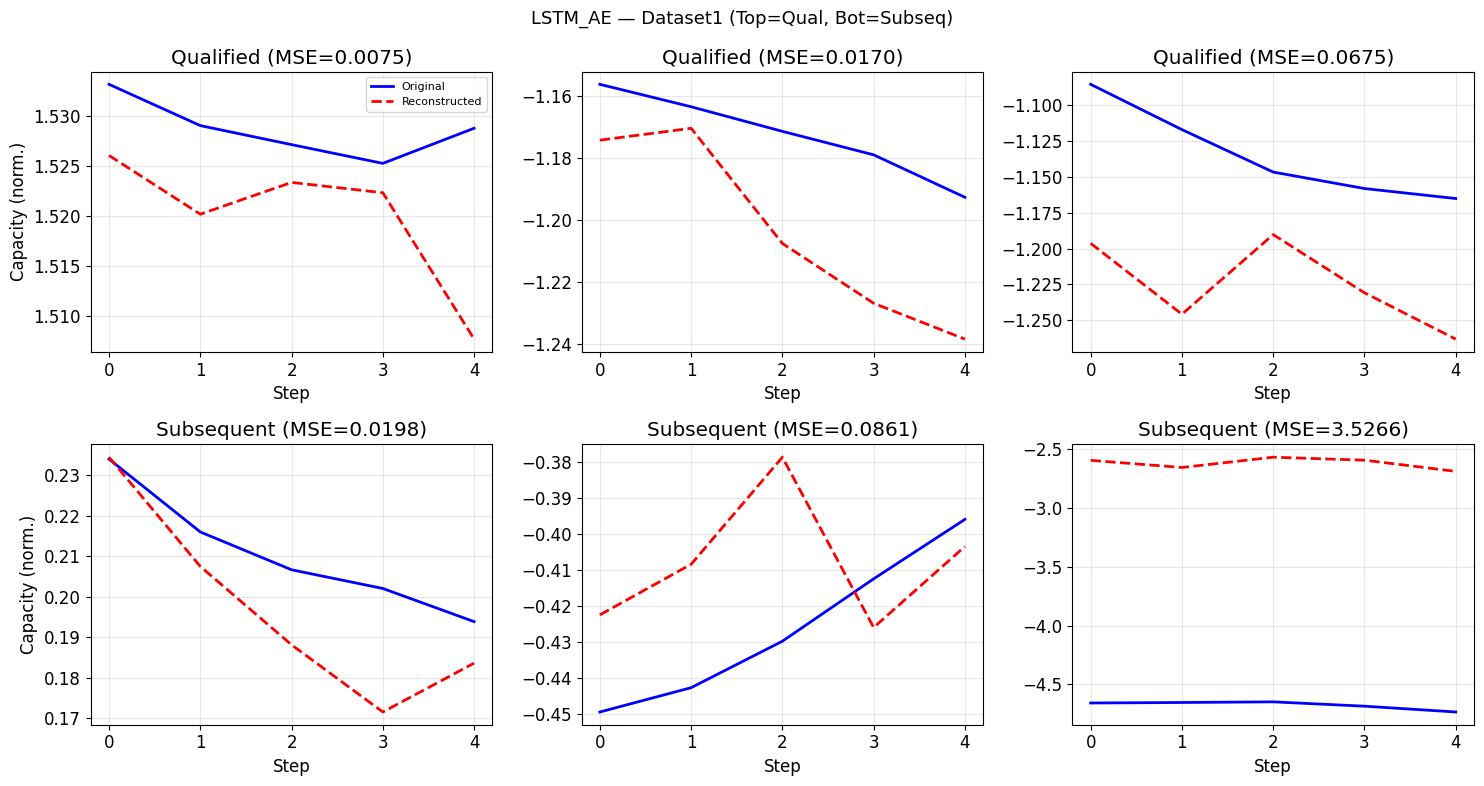

✓ LSTM_AE


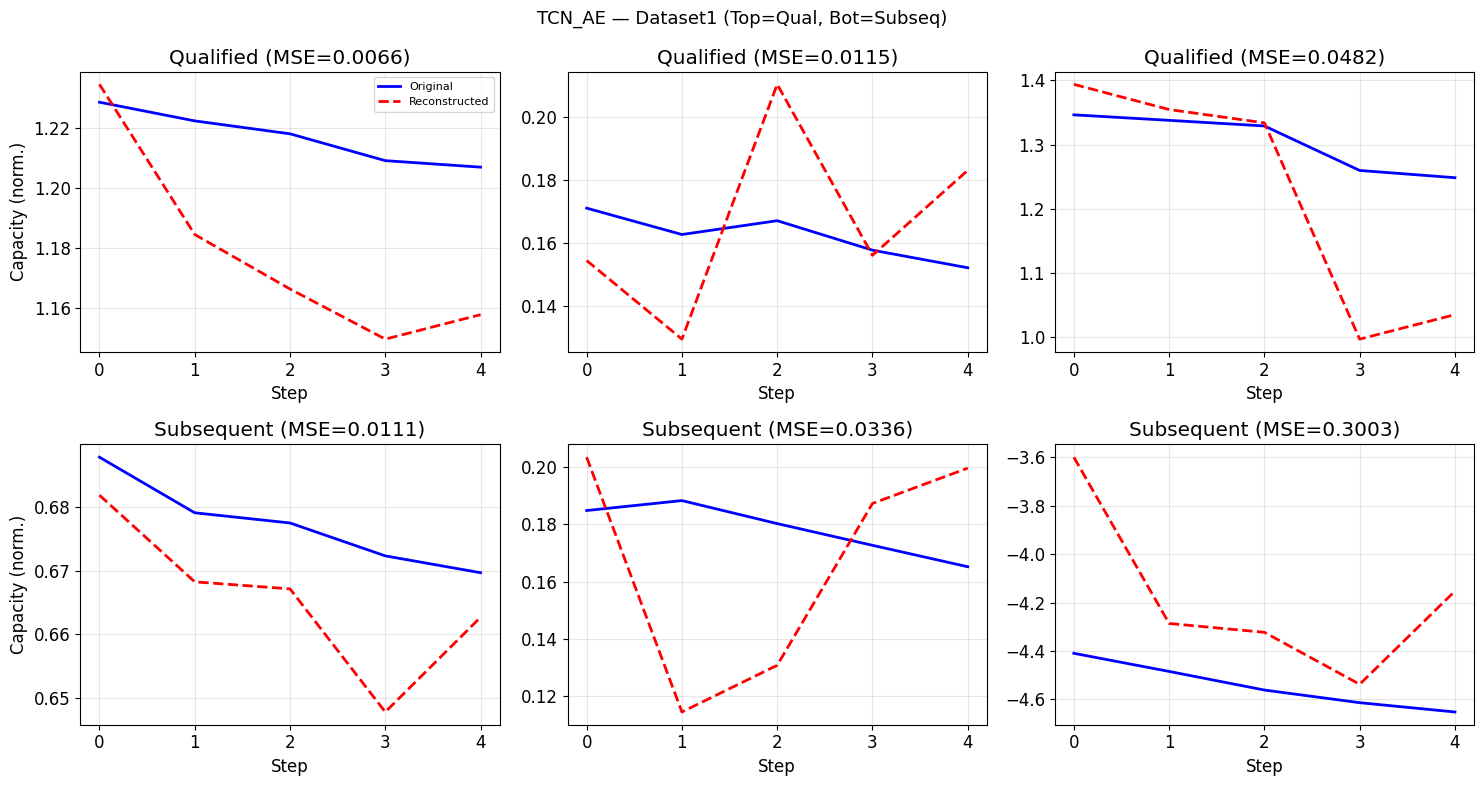

✓ TCN_AE


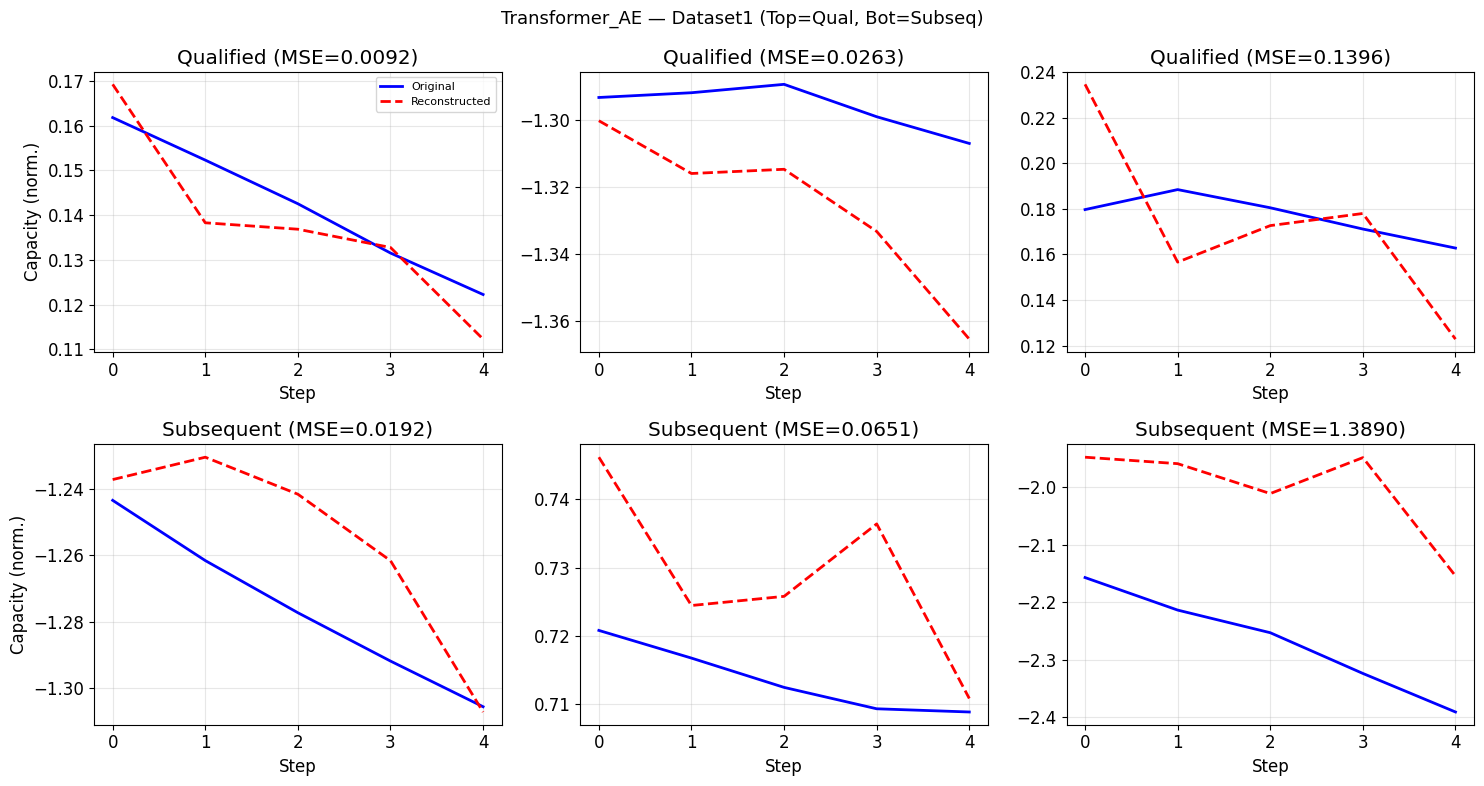

✓ Transformer_AE


In [17]:
def plot_reconstruction(model, model_name, dataset_name, n_examples=3):
 fig, axes = plt.subplots(2, n_examples, figsize=(5*n_examples, 8))
 model.eval()

 for row, grp in enumerate(['Qualified', 'Subsequent']):
 data = windows_norm[dataset_name][grp]
 data_t = torch.FloatTensor(data).to(device)
 with torch.no_grad():
 output = model(data_t)
 errors = ((output - data_t)**2).mean(dim=(1,2)).cpu().numpy()

 sorted_idx = np.argsort(errors)
 picks = [sorted_idx[len(sorted_idx)//4],
 sorted_idx[len(sorted_idx)//2],
 sorted_idx[int(len(sorted_idx)*0.9)]]

 for col, idx in enumerate(picks[:n_examples]):
 ax = axes[row, col]
 orig = data[idx, :, 0]
 recon = output[idx, :, 0].cpu().numpy()
 ax.plot(orig, 'b-', lw=2, label='Original')
 ax.plot(recon, 'r--', lw=2, label='Reconstructed')
 ax.set_title(f'{grp} (MSE={errors[idx]:.4f})')
 ax.set_xlabel('Step')
 if col == 0: ax.set_ylabel('Capacity (norm.)')
 if row == 0 and col == 0: ax.legend(fontsize=8)

 plt.suptitle(f'{model_name} — {dataset_name} (Top=Qual, Bot=Subseq)', fontsize=13)
 plt.tight_layout()
 plt.savefig(os.path.join(RESULTS_DIR,
 f'fig15_{model_name.lower()}_recon_{dataset_name.lower()}_v2.png'),
 dpi=150, bbox_inches='tight')
 plt.show()

for mn in model_configs.keys():
 plot_reconstruction(trained_models[(mn,'Dataset1')], mn, 'Dataset1')
 print(f' {mn}')

---
## 15. Save Results

In [18]:
# 1. Detection cycles (all thresholds)
dl_detection_df.to_csv(os.path.join(PROCESSED_DIR, 'dl_detection_cycles.csv'), index=False)
print(' dl_detection_cycles.csv')

# 2. Final detection (best threshold)
final_detection_df.to_csv(os.path.join(PROCESSED_DIR, 'dl_final_detection.csv'), index=False)
print(' dl_final_detection.csv')

# 3. Cell-level scores
dl_cell_scores.to_csv(os.path.join(PROCESSED_DIR, 'dl_cell_scores.csv'), index=False)
print(' dl_cell_scores.csv')

# 4. AUC
dl_auc_df.to_csv(os.path.join(PROCESSED_DIR, 'dl_auc_metrics.csv'), index=False)
print(' dl_auc_metrics.csv')

# 5. Per-cycle scores (for ensemble)
dl_percycle = {}
for mn in model_configs.keys():
 dl_percycle[mn.lower()] = dl_results[mn]
with open(os.path.join(PROCESSED_DIR, 'dl_percycle_scores.pkl'), 'wb') as f:
 pickle.dump(dl_percycle, f)
print(' dl_percycle_scores.pkl')

# 6. Combined AUC
combined_auc.to_csv(os.path.join(PROCESSED_DIR, 'combined_auc_AB.csv'), index=False)
print(' combined_auc_AB.csv')

# 7. Best threshold mapping
with open(os.path.join(PROCESSED_DIR, 'dl_best_thresholds.pkl'), 'wb') as f:
 pickle.dump(best_threshold, f)
print(' dl_best_thresholds.pkl')

print(f'\n=== All saved to {PROCESSED_DIR} ===')
for fn in sorted(os.listdir(PROCESSED_DIR)):
 fp = os.path.join(PROCESSED_DIR, fn)
 if os.path.isfile(fp):
 print(f' {fn} ({os.path.getsize(fp)/1024:.1f} KB)')

✓ dl_detection_cycles.csv
✓ dl_final_detection.csv
✓ dl_cell_scores.csv
✓ dl_auc_metrics.csv
✓ dl_percycle_scores.pkl
✓ combined_auc_AB.csv
✓ dl_best_thresholds.pkl

=== All saved to /content/drive/MyDrive/battery-anomaly-detection/processed_data ===
  baseline_auc_metrics.csv (0.4 KB)
  baseline_cell_scores.csv (10.9 KB)
  baseline_detection_cycles.csv (11.1 KB)
  baseline_percycle_scores.pkl (464.6 KB)
  combined_auc_AB.csv (0.9 KB)
  diao2020_baselines.csv (0.2 KB)
  dl_auc_metrics.csv (0.4 KB)
  dl_best_thresholds.pkl (0.1 KB)
  dl_cell_scores.csv (8.5 KB)
  dl_detection_cycles.csv (25.5 KB)
  dl_final_detection.csv (8.6 KB)
  dl_percycle_scores.pkl (418.9 KB)
  features_all.csv (1730.7 KB)
  gaf_images_full.pkl (3363.1 KB)
  gaf_images_progressive.pkl (27560.6 KB)
  ground_truth_d1.csv (0.6 KB)
  ground_truth_d2.csv (1.0 KB)
  sliding_windows.pkl (5707.9 KB)
  smoothed_capacity.pkl (188.2 KB)


---
## 16. Branch B v2 Summary

### v2 Improvements
| Change | v1 | v2 |
|---|---|---|
| LSTM hidden | 64 | 128 |
| Latent dim | 16 | 32 |
| TCN encoder | 2 blocks [32,64] | 3 blocks [32,64,128] |
| TCN decoder | Broken (bypassed) | ConvTranspose1d mirror |
| Transformer | d=64, 2 layers, 4 heads | d=128, 3 layers, 8 heads |
| FC layers | Single linear | 2-layer MLP with nonlinearity |
| Optimizer | Adam | AdamW (weight_decay=1e-4) |
| Scheduler | ReduceLROnPlateau | CosineAnnealingWarmRestarts |
| Epochs | 150 | 300 |
| Patience | 15 | 25 |
| Anomaly score | Uniform MSE | Feature-weighted MSE |
| Threshold | mean+3σ only | Multi-threshold with auto-selection |

### Next
- **05_gaf_image_models.ipynb** -> Branch C: PatchCore, CNN-AE, EfficientAD
- **06_ensemble_evaluation.ipynb** -> Combine A + B + C

In [19]:
print('=== Branch B v2 Complete ===')
print('\nReady for:')
print(' 05_gaf_image_models.ipynb -> Branch C (PatchCore, CNN-AE, EfficientAD)')
print(' 06_ensemble_evaluation.ipynb -> Combine all branches')

=== Branch B v2 Complete ===

Ready for:
  05_gaf_image_models.ipynb → Branch C (PatchCore, CNN-AE, EfficientAD)
  06_ensemble_evaluation.ipynb → Combine all branches
